### "*How well can lifestyle and health-related factors predict an individual’s cognitive health, as measured by their MMSE score?*"

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The Alzheimer's disease dataset was created by Rabie El Kharoua. I accessed the dataset through Kaggle. The dataset aligns with SDG 3: Good Health and Well Being as the model can inform general population about risk factors of Alzheimer's.

In [3]:
alz_data=pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/Final Assessment/Dataset/alzheimers_disease_data.csv")
alz_data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [4]:
#All the columns in the dataset
alz_data.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

# 1. Exploratory Data Analysis, Statistical Interpretation and Visualizations

In [5]:
#Making a copy of the dataframe for regression task
alz_data_reg=alz_data.copy()
alz_data_reg.sample(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
590,5341,71,0,0,1,21.245159,0,10.662947,1.327255,4.397276,...,0,0,5.874476,1,1,0,0,0,0,XXXConfid
1467,6218,69,1,3,2,30.691632,1,15.322486,9.804802,5.858321,...,0,0,9.499814,0,0,0,0,0,0,XXXConfid
1111,5862,63,1,1,3,35.351722,0,16.297610,7.326076,9.905637,...,0,0,3.836561,0,0,0,0,0,0,XXXConfid
2091,6842,64,0,0,1,29.087306,0,19.783623,8.823072,2.304242,...,0,1,4.559788,0,0,0,0,1,0,XXXConfid
1227,5978,84,1,0,1,33.684210,0,9.458691,1.159983,4.150397,...,0,1,5.306796,0,0,0,0,1,1,XXXConfid


In [6]:
#Shape of the dataframe (row,column)
alz_data_reg.shape

(2149, 35)

In [7]:
alz_data_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [8]:
#Checking missing values
alz_data_reg.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [9]:
#Checking for duplicate rows
alz_data_reg.duplicated().sum()

0

In [10]:
#Removing PatientID column as it doesnot hold significance for predicting MMSE
alz_data_reg=alz_data_reg.drop(columns=['PatientID'])
alz_data_reg.head(2)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid


In [11]:
#Identifying columns with dtype object
alz_data_reg.select_dtypes(include=['object']).columns

Index(['DoctorInCharge'], dtype='object')

In [12]:
#Checking unique values of DoctorInCharge
alz_data_reg['DoctorInCharge'].unique()

array(['XXXConfid'], dtype=object)

DoctorInCharge column is confidential value as stated by the dataset provider.<br>
Removing the DoctorInCharge column because all rows have same value, so it doesnot influence MMSE score

In [13]:
alz_data_reg=alz_data_reg.drop(columns=['DoctorInCharge'])
alz_data_reg.head(2)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0


In [14]:
#Checking the number of unique values of every column
alz_data_reg.nunique()

,0
Age,31
Gender,2
Ethnicity,4
EducationLevel,4
BMI,2149
Smoking,2
AlcoholConsumption,2149
PhysicalActivity,2149
DietQuality,2149
SleepQuality,2149


In [15]:
#Checking unique values
for col in alz_data_reg.columns:
    unique_values = alz_data_reg[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values ({len(unique_values)}): {unique_values[:10]}")  #Printing only first 10 unique values
    print("-" * 50) # Prints the dashed separator line of 50 dahses

Column: Age
Unique Values (31): [73 89 74 86 68 75 72 87 78 84]
--------------------------------------------------
Column: Gender
Unique Values (2): [0 1]
--------------------------------------------------
Column: Ethnicity
Unique Values (4): [0 3 1 2]
--------------------------------------------------
Column: EducationLevel
Unique Values (4): [2 0 1 3]
--------------------------------------------------
Column: BMI
Unique Values (2149): [22.92774923 26.82768119 17.79588244 33.80081704 20.71697383 30.62688555
 38.38762186 18.77600941 27.83318838 35.45630173]
--------------------------------------------------
Column: Smoking
Unique Values (2): [0 1]
--------------------------------------------------
Column: AlcoholConsumption
Unique Values (2149): [13.29721773  4.54252382 19.55508453 12.20926555 18.45435609  4.14014378
  0.64604727 13.72382571 12.16784763 16.02868824]
--------------------------------------------------
Column: PhysicalActivity
Unique Values (2149): [6.32711247 7.61988454 

In the ethnicity column, there are three values: <br> 0: Caucasian<br> 1: African American <br> 2: Asian <br> 3: Other<br>
These are nominal categories, which means they have no order. So we one hot encode them to prevent the model from assuming orders

In [16]:
alz_data_reg = pd.get_dummies(alz_data_reg, columns=['Ethnicity'], prefix=['Ethnicity'],dtype=int)
alz_data_reg.head(2)

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_0,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,73,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,...,0,0,0,1,0,0,1,0,0,0
1,89,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,...,0,0,0,0,1,0,1,0,0,0


Dropping one of the encoded columns to prevent multicollinearity issue.<br>
In the columns Ethnicity_0,1,2,3, if we know the value of 3 columns, we can predict the 4th column. This can lead to overfitting

In [17]:
alz_data_reg = alz_data_reg.drop(columns=['Ethnicity_0'])
alz_data_reg.head(2)

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,73,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,...,1.725883,0,0,0,1,0,0,0,0,0
1,89,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,...,2.592424,0,0,0,0,1,0,0,0,0


In [18]:
#Transpose
alz_data_reg.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840
FamilyHistoryAlzheimers,2149.0,0.252210,0.434382,0.000000,0.000000,0.000000,1.000000,1.000000


In [19]:
#Finding outliers for columns except for binary and ordinal
for col in alz_data_reg.columns:
    if alz_data_reg[col].nunique() > 4:
        Q1 = alz_data_reg[col].quantile(0.25)
        Q3 = alz_data_reg[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = (alz_data_reg[col] < lower_bound) | (alz_data_reg[col] > upper_bound)
        num_outliers = outliers.sum()
        print(f"{col}:{num_outliers}")

Age:0
BMI:0
AlcoholConsumption:0
PhysicalActivity:0
DietQuality:0
SleepQuality:0
SystolicBP:0
DiastolicBP:0
CholesterolTotal:0
CholesterolLDL:0
CholesterolHDL:0
CholesterolTriglycerides:0
MMSE:0
FunctionalAssessment:0
ADL:0


Text(0.5, 1.0, 'Ditribution of MMSE')

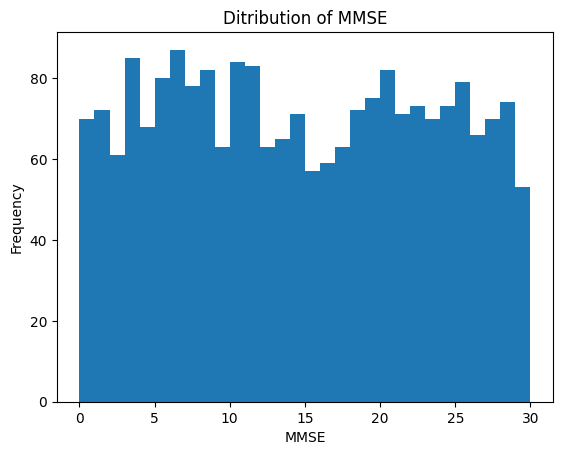

In [20]:
#Distribution across MMSE
plt.hist(alz_data_reg['MMSE'],bins=30)
plt.xlabel('MMSE')
plt.ylabel('Frequency')
plt.title('Ditribution of MMSE')

The MMSE score is evenly distributed, with no strong skewness present. There are also no significant peaks.

Text(0.5, 1.0, 'Boxplot of Features to Detect Outliers')

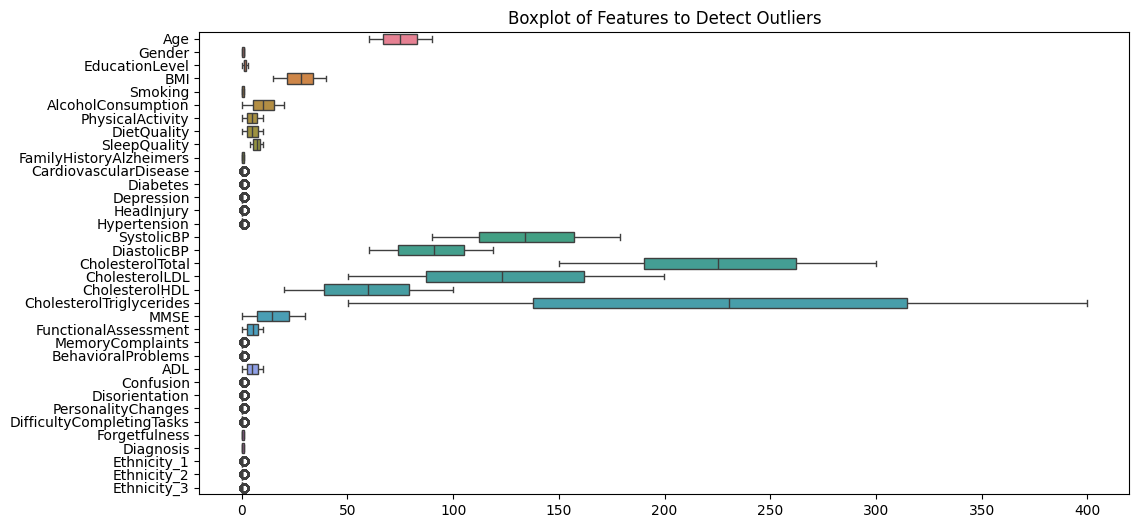

In [21]:
#Boxplot of all Features
plt.figure(figsize=(12, 6))
sns.boxplot(data=alz_data_reg, orient="h")
plt.title("Boxplot of Features to Detect Outliers")

 The plots where outliers are present are categorical columns. These columns have binary values 0,1 so the boxplot considers the range as [0-1] and the values 0,1 are misinterpreted as extreme.

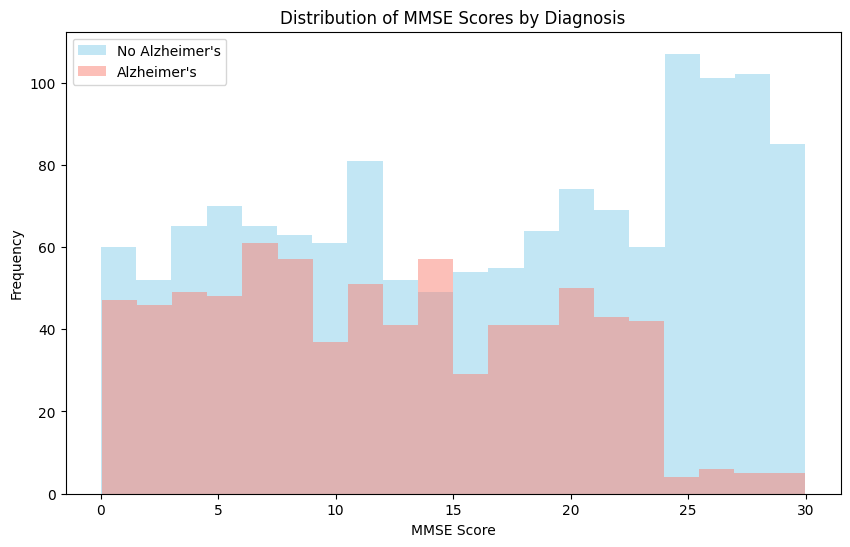

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(alz_data_reg[alz_data_reg['Diagnosis'] == 0]['MMSE'], bins=20, alpha=0.5, label='No Alzheimer\'s', color='skyblue')
plt.hist(alz_data_reg[alz_data_reg['Diagnosis'] == 1]['MMSE'], bins=20, alpha=0.5, label='Alzheimer\'s', color='salmon')
plt.xlabel('MMSE Score')
plt.ylabel('Frequency')
plt.title('Distribution of MMSE Scores by Diagnosis')
plt.legend()

The above histogram describes the frequency of MMSE scores across people with ALzheimer's and no Alzheimer's.<br>We can observe that most of the people who are not diagnosed with Alzheimer's have MMSE scores in range 25-30. The histogram for No Alzheimer's is left skewed.<br>For the histogram of Alzheimer's, there is no significant peak but most MMSE scores are below 25. A score below 24 could describe cognitive impairment.<br>The histogram suggests that the people with Alzheimer's have lower MMSE scores comparatively.

In [47]:
from scipy.stats import pearsonr
for col in alz_data_reg.columns:
  if col!="MMSE":
    correlation_value = alz_data_reg['MMSE'].corr(alz_data_reg[col], method='pearson')
    print(f"Pearson Correlation Coefficient between MMSE and {col}: {correlation_value}")

Pearson Correlation Coefficient between MMSE and Age: -0.004234771200121305
Pearson Correlation Coefficient between MMSE and Gender: 0.025329890311331697
Pearson Correlation Coefficient between MMSE and EducationLevel: 0.0260899292466416
Pearson Correlation Coefficient between MMSE and BMI: -0.0034767068601193798
Pearson Correlation Coefficient between MMSE and Smoking: 0.002138890793063697
Pearson Correlation Coefficient between MMSE and AlcoholConsumption: -0.01142398959852098
Pearson Correlation Coefficient between MMSE and PhysicalActivity: -0.008342257095075278
Pearson Correlation Coefficient between MMSE and DietQuality: 0.0216364080598454
Pearson Correlation Coefficient between MMSE and SleepQuality: 0.012506135301846402
Pearson Correlation Coefficient between MMSE and FamilyHistoryAlzheimers: 0.015574666836845484
Pearson Correlation Coefficient between MMSE and CardiovascularDisease: 0.0253506308200164
Pearson Correlation Coefficient between MMSE and Diabetes: -0.00890521549398

Text(0.5, 1.0, 'MMSE vs SleepQuality')

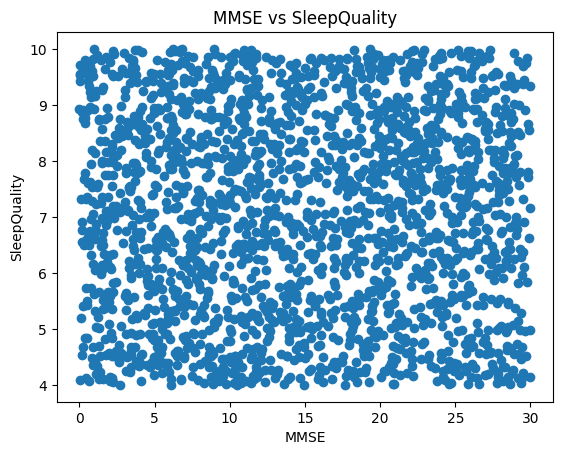

In [42]:
plt.scatter(x=alz_data['MMSE'],y=alz_data['SleepQuality'])
plt.xlabel("MMSE")
plt.ylabel("SleepQuality")
plt.title('MMSE vs SleepQuality')

The data points appear to be randomly scattered without any increasing or decreasing pattern(trend). There is no linear relationship among SleepQuality and MMSE. This suggests that SleepQuality maynot have a strong predicitive relationship with MMSE.

Text(0.5, 1.0, 'MMSE vs FunctionalAssessment')

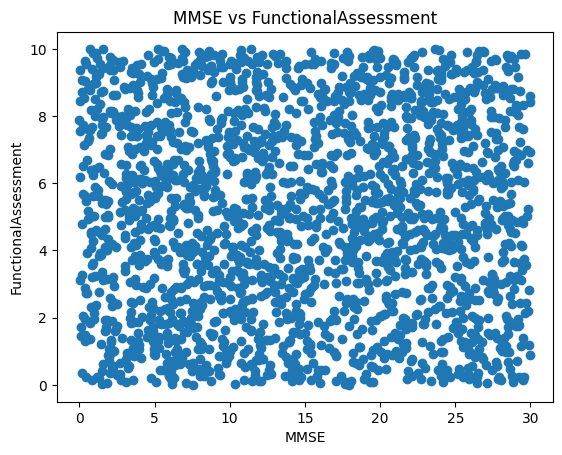

In [43]:
plt.scatter(x=alz_data['MMSE'],y=alz_data['FunctionalAssessment'])
plt.xlabel("MMSE")
plt.ylabel("FunctionalAssessment")
plt.title('MMSE vs FunctionalAssessment')

Text(0.5, 1.0, 'MMSE vs ADL')

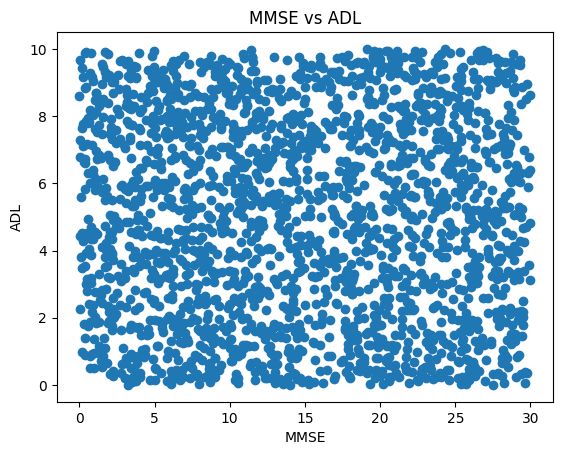

In [44]:
plt.scatter(x=alz_data['MMSE'],y=alz_data['ADL'])
plt.xlabel("MMSE")
plt.ylabel("ADL")
plt.title('MMSE vs ADL')

# 2. Build a Model from Scratch (Linear Regression)

In [23]:
class LinearRegressionScratch:
    def __init__(self, alpha=0.01, iterations=1000, lambda_=0.1):
        self.alpha = alpha
        self.iterations = iterations
        self.lambda_ = lambda_  # Regularization strength
        self.W = None
        self.b = None  # Separate bias term

    def fit(self, X, y):
        # Initialize weights and bias
        self.W = np.zeros(X.shape[1])  # Initialize weights to zeros (excluding bias)
        self.b = 0  # Initialize bias to zero

        # Perform gradient descent with L2 regularization
        self.W, self.b, cost_history = self.gradient_descent(X, y, self.W, self.b, self.alpha, self.iterations, self.lambda_)
        self.coef_ = self.W  # Store the weights in coef_ attribute for feature selection
        return self

    def predict(self, X):
        # Predict using the updated weights and bias term
        return np.dot(X, self.W) + self.b  # Adding bias term to prediction

    def gradient_descent(self, X, Y, W, b, alpha, iterations, lambda_):
        cost_history = [0] * iterations
        m = len(Y)
        for iteration in range(iterations):
            Y_pred = np.dot(X, W) + b  # Include bias term in prediction
            loss = Y_pred - Y

            # Compute gradients
            dw = (1/m) * np.dot(X.T, loss) + (lambda_ / m) * W  # L2 regularization term added to weight gradients
            db = (1/m) * np.sum(loss)  # Gradient for bias (no regularization)

            # Update weights and bias
            W = W - alpha * dw
            b = b - alpha * db  # Update bias separately

            cost_history[iteration] = self.cost_function(X, Y, W, b, lambda_)

        return W, b, cost_history

    def cost_function(self, X, Y, W, b, lambda_):
        # L2 regularization term
        l2_term = (lambda_ / (2 * len(Y))) * np.sum(W**2)  # Corrected L2 regularization
        cost = (1/(2*len(Y))) * np.sum((np.dot(X, W) + b - Y)**2) + l2_term
        return cost

    def rmse(self, Y, Y_pred):
        rmse = np.sqrt(np.mean((Y - Y_pred)**2))
        return rmse

    def r2(self, Y, Y_pred):
        mean_y = np.mean(Y)
        ss_tot = np.sum((Y - mean_y)**2)
        ss_res = np.sum((Y - Y_pred)**2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

    def get_params(self, deep=True):
        """Return the hyperparameters of the model."""
        return {"alpha": self.alpha, "iterations": self.iterations, "lambda_": self.lambda_}

    def set_params(self, **params):
        """Set the hyperparameters of the model."""
        for param, value in params.items():
            setattr(self, param, value)
        return self

In [24]:
#Splitting target and feature variable
X=alz_data_reg.drop(columns=['MMSE']).values
y=alz_data_reg['MMSE'].values

In [25]:
def train_test_split_scratch(X, y, test_size=0.2, random_seed=42):
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices) # Shuffle the indices
  test_split_size = int(len(X) * test_size)
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test

In [26]:
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.2)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1720, 34)
Shape of X_test: (429, 34)
Shape of y_train: (1720,)
Shape of y_test: (429,)


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)#Only transform for test set

In [28]:
def linear_regression_scratch_model(alpha, iterations):
  model = LinearRegressionScratch(alpha=alpha, iterations=iterations)
  model.fit(X_train, y_train)
  y_test_pred = model.predict(X_test)
  y_train_pred = model.predict(X_train)
  #For test set
  rmse_test = model.rmse(y_test, y_test_pred)
  r2_test = model.r2(y_test, y_test_pred)
  #For train set
  rmse_train = model.rmse(y_train, y_train_pred)
  r2_train = model.r2(y_train, y_train_pred)
  print("FOR LINEAR REGRESSION FROM SCRATCH")
  print("Test RMSE:", rmse_test)
  print("Test R2:", r2_test)
  print("Train RMSE:", rmse_train)
  print("Train R2:", r2_train)
linear_regression_scratch_model(0.01,10000)

FOR LINEAR REGRESSION FROM SCRATCH
Test RMSE: 8.050541523624593
Test R2: 0.10384763801102825
Train RMSE: 8.236594785576125
Train R2: 0.09069031693205454


## Evaluation for LinearRegression from Scratch
The RMSE on both train (8.23) and test set (8.05) is high. The predicted values deviate significantly from actual values.<br><br>The R2 scores for test set (0.1038) and train set (0.0906) is also low and very close to 0, which indicates that the model cannot predict much of the variance in the data.<br><br>The model is underfitting because both train and test have similar evaluation results but the model is performing poor on the data.

# 3. DecisionTreeRegressor using scikit learn

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [30]:
decision_tree_model = DecisionTreeRegressor(random_state=42, max_depth=5)
decision_tree_model.fit(X_train, y_train)
#For Train set
y_train_pred = decision_tree_model.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("FOR DECISION TREE REGRESSOR")
print("For train set:")
print(f"Root Mean Squared Error (RMSE): {rmse_train}")
print(f"R2 Score: {r2_train}")
#For Test set
y_test_pred = decision_tree_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("For test set:")
print(f"Root Mean Squared Error (RMSE): {rmse_test}")
print(f"R2 Score: {r2_test}")

FOR DECISION TREE REGRESSOR
For train set:
Root Mean Squared Error (RMSE): 7.6639583203430375
R2 Score: 0.2127318477514245
For test set:
Root Mean Squared Error (RMSE): 8.113783588617348
R2 Score: 0.08971265522276206


## Evaluation for DecisionTreeRegressor
The DecisionTreeRegressor Model is overfitting due to worse performances in test set than train set. In train set, the RMSE is 7.66 but in test set the RMSE increased to 8.11. Similarly, the R2 score in train set is 0.21 but in test set it became 0.089 which is lower. This means that the model is not generalizing well to unseen data.

## Identifying the better model
Root Mean Squared Error (RMSE) (Lower is better)

* ### Train RMSE:<br>
Linear Regression: 8.2365<br>
Decision Tree: 7.66 (Better)<br>
* ### Test RMSE:<br>
Linear Regression: 8.0505 (Better)<br>
Decision Tree: 8.11 <br>

R2 Score (Higher is better)

* ### Train R2:
Linear Regression: 0.0906<br>
Decision Tree: 0.2127(Better)<br>
* ### Test R2:<br>
Linear Regression: 0.103(Better)<br>
Decision Tree: 0.0897<br><br>

Decision Tree overfits but it performs slightly better than Linear Regression from scratch in train set. Linear Regression is underfitting but it's values are worser compared to train results of DecisionTree. So, Decision Tree would be a better model for my dataset because hyperparameter optimizations like max_depth could help in preventing overfitting.

# 4. Hyper-parameter Optimization with Cross-Validation

## For Linear Regression from Scratch

In [31]:
from sklearn.model_selection import RandomizedSearchCV

In [32]:
param_distributions = {
    'alpha': np.logspace(-4, -1, 10),
    'iterations': list(range(5000, 50000, 5000)),
    'lambda_': np.logspace(-3, 2, 6)  # Regularization strength
}
random_search_LR = RandomizedSearchCV(
    estimator=LinearRegressionScratch(),
    param_distributions=param_distributions,
    n_iter=10,  # Number of random combinations to test
    cv=5,  # Cross-validation with 5 splits
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

In [33]:
random_search_LR.fit(X_train,y_train)
print("FOR LINEAR REGRESSION FROM SCRATCH:")
print(f"Best Hyperparameters: {random_search_LR.best_params_}")
print(f"Best Score: {random_search_LR.best_score_}")

FOR LINEAR REGRESSION FROM SCRATCH:
Best Hyperparameters: {'lambda_': 100.0, 'iterations': 30000, 'alpha': 0.1}
Best Score: -71.19049298100933


## For DecisionTreeRegressor

In [34]:
param_distributions = {
    'criterion': ['squared_error', 'friedman_mse', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 50, 100],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 50, 100],
    'min_impurity_decrease': [0.0, 0.01, 0.1, 0.2],
    'random_state': [42]
}
random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(),
    param_distributions=param_distributions,
    n_iter=100,  # Number of random combinations to sample
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all cores
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1  # For detailed output
)
random_search.fit(X_train, y_train)
print("FOR DECISION TREE REGRESSOR")
print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"Best Cross-Validation Score: {random_search.best_score_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
FOR DECISION TREE REGRESSOR
Best Hyperparameters: {'splitter': 'best', 'random_state': 42, 'min_samples_split': 10, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': 10, 'max_features': None, 'max_depth': 30, 'criterion': 'friedman_mse'}
Best Cross-Validation Score: -70.26230493436063


# 5. Feature Selection

## For Linear Regression

In [35]:
from sklearn.feature_selection import RFE

In [36]:
X=alz_data_reg.drop(columns=['MMSE'])
y=alz_data_reg['MMSE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test),columns=X.columns)

In [37]:
model = LinearRegressionScratch()
rfe_LR = RFE(estimator=model, n_features_to_select=20)
rfe_LR.fit(X_train,y_train)
selected_features_LR = X_train.columns[rfe_LR.support_]
print("FOR LINEAR REGRESSION FROM SCRATCH")
print(f"Selected Features: {selected_features_LR}")

FOR LINEAR REGRESSION FROM SCRATCH
Selected Features: Index(['Age', 'Gender', 'AlcoholConsumption', 'DietQuality',
       'CardiovascularDisease', 'Diabetes', 'Depression', 'Hypertension',
       'DiastolicBP', 'CholesterolHDL', 'CholesterolTriglycerides',
       'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL',
       'Disorientation', 'PersonalityChanges', 'Diagnosis', 'Ethnicity_1',
       'Ethnicity_2'],
      dtype='object')


## For DecisionTreeRegressor

In [38]:
model = DecisionTreeRegressor()
rfe_DT = RFE(estimator=model, n_features_to_select=20)
rfe_DT.fit(X_train, y_train)
selected_features_DT = X_train.columns[rfe_DT.support_]
print("FOR DECISION TREE REGRESSOR")
print(f"Selected Features: {selected_features_DT}")

FOR DECISION TREE REGRESSOR
Selected Features: Index(['Age', 'EducationLevel', 'BMI', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'FunctionalAssessment', 'MemoryComplaints',
       'BehavioralProblems', 'ADL', 'Diagnosis', 'Ethnicity_1', 'Ethnicity_2'],
      dtype='object')


# 6. Final Model

## DecisionTreeRegressor

In [39]:
X_train_selected = X_train[selected_features_DT]
X_test_selected = X_test[selected_features_DT]
# Best hyperparameters (from previous search)
decision_tree_model = DecisionTreeRegressor(**random_search.best_params_)
decision_tree_model.fit(X_train_selected, y_train)
y_test_pred = decision_tree_model.predict(X_test_selected)
y_train_pred = decision_tree_model.predict(X_train_selected)
#For test set
rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
#For train set
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("FOR DECISION TREE REGRESSOR")
print("Test RMSE:", rmse_test)
print("Test R2:", r2_test)
print("Train RMSE:", rmse_train)
print("Train R2:", r2_train)

FOR DECISION TREE REGRESSOR
Test RMSE: 7.830581840484123
Test R2: 0.1527874723440117
Train RMSE: 7.977279504522296
Train R2: 0.14689506126366858


## Linear Regression from Scratch

In [40]:
X_train_selected = X_train[selected_features_LR]
X_test_selected = X_test[selected_features_LR]
# Best hyperparameters (from previous search)
best_alpha = random_search_LR.best_params_['alpha']
best_iterations = random_search_LR.best_params_['iterations']
best_lambda=random_search_LR.best_params_['lambda_']
model = LinearRegressionScratch(alpha=best_alpha, iterations=best_iterations,lambda_=best_lambda)
model.fit(X_train_selected, y_train)
y_test_pred = model.predict(X_test_selected)
y_train_pred = model.predict(X_train_selected)
#For test set
rmse_test = model.rmse(y_test, y_test_pred)
r2_test = model.r2(y_test, y_test_pred)
#For train set
rmse_train = model.rmse(y_train, y_train_pred)
r2_train = model.r2(y_train, y_train_pred)
print("FOR LINEAR REGRESSION FROM SCRATCH")
print("Test RMSE:", rmse_test)
print("Test R2:", r2_test)
print("Train RMSE:", rmse_train)
print("Train R2:", r2_train)

FOR LINEAR REGRESSION FROM SCRATCH
Test RMSE: 8.065153034469603
Test R2: 0.10126940147099261
Train RMSE: 8.24286259785889
Train R2: 0.08914560255191828


# 7. Conclusion

After applying Cross-Validation and Feature selection, the decision tree regressor model performs slightly better on unseen data, meaning it doesnot overfit like before.